
Building Master OS Graph...


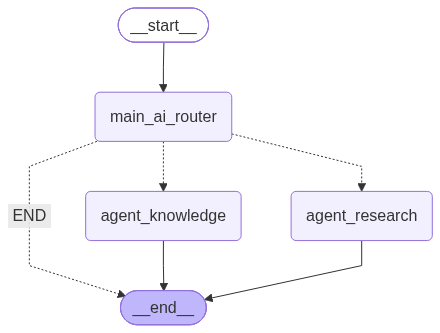

In [1]:
# Required installations for Jupyter:
# !pip install langgraph IPython

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

# Dummy state to keep the graphs happy
class DummyState(TypedDict):
    dummy: str

def dummy_node(state):
    return state

# ==========================================
# 1. THE MASTER GRAPH (THE ROUTER OS)
# ==========================================
print("\nBuilding Master OS Graph...")
master = StateGraph(DummyState)

master.add_node("main_ai_router", dummy_node)
master.add_node("agent_knowledge", dummy_node)
master.add_node("agent_research", dummy_node)

def route_request(state):
    return "agent_research" # or agent_knowledge or END

master.add_edge(START, "main_ai_router")

master.add_conditional_edges(
    "main_ai_router",
    route_request,
    {
        "agent_knowledge": "agent_knowledge",
        "agent_research": "agent_research",
        "END": END
    }
)

master.add_edge("agent_knowledge", END)
master.add_edge("agent_research", END)

master_graph = master.compile()
display(Image(master_graph.get_graph().draw_mermaid_png()))



Building Knowledge Agent Graph...


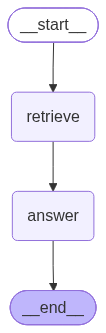

In [4]:
# ==========================================
# 2. THE KNOWLEDGE AGENT GRAPH
# ==========================================
print("\nBuilding Knowledge Agent Graph...")
knowledge = StateGraph(DummyState)

knowledge.add_node("retrieve", dummy_node) # This node secretly runs CRAG/Self-RAG under the hood
knowledge.add_node("answer", dummy_node)

knowledge.add_edge(START, "retrieve")
knowledge.add_edge("retrieve", "answer")
knowledge.add_edge("answer", END)

knowledge_graph = knowledge.compile()
display(Image(knowledge_graph.get_graph().draw_mermaid_png()))



Building Knowledge Agent (CRAG) Graph...


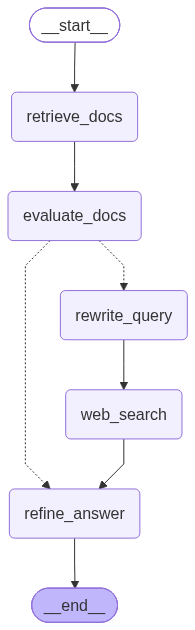

In [2]:

# ==========================================
# 2. THE KNOWLEDGE AGENT (CRAG) GRAPH
# ==========================================
print("\nBuilding Knowledge Agent (CRAG) Graph...")
crag = StateGraph(DummyState)
crag.add_node("retrieve_docs", dummy_node)
crag.add_node("evaluate_docs", dummy_node)
crag.add_node("rewrite_query", dummy_node)
crag.add_node("web_search", dummy_node)
crag.add_node("refine_answer", dummy_node)

# Dummy conditional router
def route_after_eval(state):
    return "rewrite_query" # or refine_answer

crag.add_edge(START, "retrieve_docs")
crag.add_edge("retrieve_docs", "evaluate_docs")

crag.add_conditional_edges(
    "evaluate_docs",
    route_after_eval,
    {
        "rewrite_query": "rewrite_query",
        "refine_answer": "refine_answer"
    }
)
crag.add_edge("rewrite_query", "web_search")
crag.add_edge("web_search", "refine_answer")
crag.add_edge("refine_answer", END)

crag_graph = crag.compile()
display(Image(crag_graph.get_graph().draw_mermaid_png()))


Building Research Agent Graph...


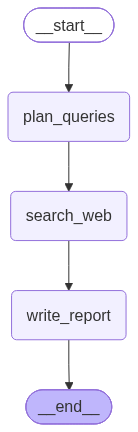

In [3]:
# ==========================================
# 3. THE RESEARCH AGENT GRAPH
# ==========================================
print("Building Research Agent Graph...")
research = StateGraph(DummyState)
research.add_node("plan_queries", dummy_node)
research.add_node("search_web", dummy_node)
research.add_node("write_report", dummy_node)

research.add_edge(START, "plan_queries")
research.add_edge("plan_queries", "search_web")
research.add_edge("search_web", "write_report")
research.add_edge("write_report", END)

research_graph = research.compile()
display(Image(research_graph.get_graph().draw_mermaid_png()))